In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [3]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print(df["TotalCharges"].head(10))

print("\nUnique Python Type:")
print(type(df["TotalCharges"].iloc[0]))

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

Unique Python Type:
<class 'str'>


In [5]:
blank_spaces = (df["TotalCharges"].str.strip() == "").sum()

print("Blank entries:", blank_spaces)

Blank entries: 11


In [6]:
problem_rows = df[df["TotalCharges"].str.strip() == ""]

print(problem_rows.shape)

problem_rows.head()

(11, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


In [7]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(df["TotalCharges"].dtype)

print("\nMissing values after conversion:")
print(df["TotalCharges"].isnull().sum())

float64

Missing values after conversion:
11


In [8]:
print(df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]])

      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


In [9]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing values after filling:")
print(df["TotalCharges"].isnull().sum())

Missing values after filling:
0


In [10]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
print(df["Churn"].value_counts())

print("\nPercentage Distribution:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage Distribution:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


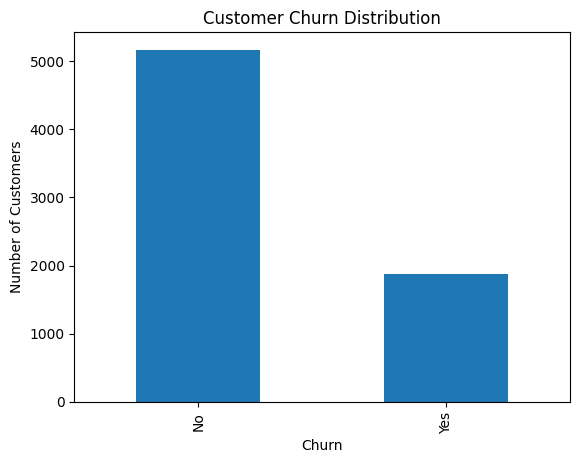

In [12]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [13]:
print(df[["tenure", "MonthlyCharges", "TotalCharges"]].describe())

            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2279.734304
std      24.559481       30.090047   2266.794470
min       0.000000       18.250000      0.000000
25%       9.000000       35.500000    398.550000
50%      29.000000       70.350000   1394.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


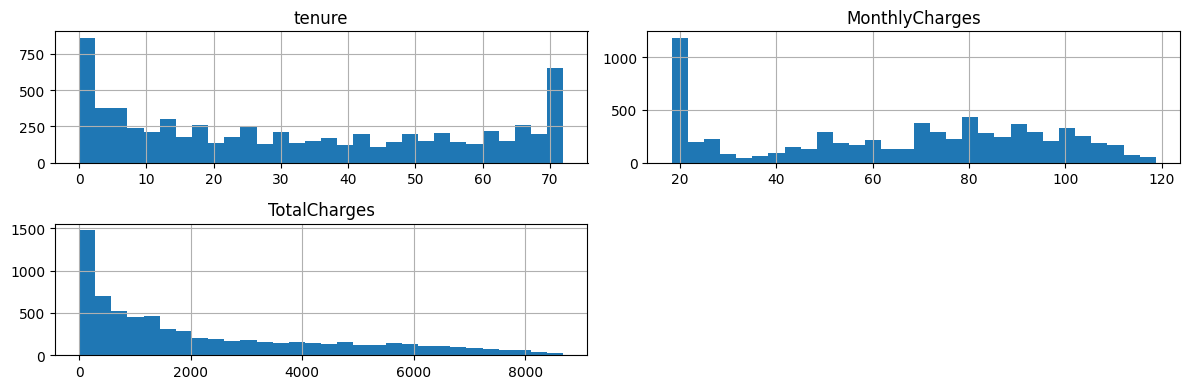

In [14]:
import matplotlib.pyplot as plt

df[["tenure", "MonthlyCharges", "TotalCharges"]].hist(
    figsize=(12, 4),
    bins=30
)

plt.tight_layout()
plt.show()

In [15]:
print(
    df[["tenure", "MonthlyCharges", "TotalCharges"]]
    .corr()
)

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.247900      0.826178
MonthlyCharges  0.247900        1.000000      0.651174
TotalCharges    0.826178        0.651174      1.000000


In [16]:
print(
    df.groupby("Churn")[
        ["tenure", "MonthlyCharges", "TotalCharges"]
    ].mean()
)

          tenure  MonthlyCharges  TotalCharges
Churn                                         
No     37.569965       61.265124   2549.911442
Yes    17.979133       74.441332   1531.796094


In [17]:
categorical_cols = df.select_dtypes(include="object").columns

print("Number of categorical columns:", len(categorical_cols))
print("\nCategorical Columns:\n")
print(list(categorical_cols))

Number of categorical columns: 17

Categorical Columns:

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


C:\Users\rishi\AppData\Local\Temp\ipykernel_5752\2206271484.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [18]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== customerID =====
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

===== gender =====
gender
Male      3555
Female    3488
Name: count, dtype: int64

===== Partner =====
Partner
No     3641
Yes    3402
Name: count, dtype: int64

===== Dependents =====
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

===== PhoneService =====
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

===== MultipleLines =====
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

===== InternetService =====
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

===== OnlineSecurity =====
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, 

In [19]:
print(df["Contract"].value_counts())

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


In [20]:
print(df["InternetService"].value_counts())

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


In [21]:
print(df["PaymentMethod"].value_counts())

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [22]:
print(df["Partner"].value_counts())

Partner
No     3641
Yes    3402
Name: count, dtype: int64


In [23]:
print(df["Dependents"].value_counts())

Dependents
No     4933
Yes    2110
Name: count, dtype: int64


In [24]:
print(
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    ) * 100
)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [25]:
print(
    pd.crosstab(
        df["InternetService"],
        df["Churn"],
        normalize="index"
    ) * 100
)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


In [26]:
print(
    pd.crosstab(
        df["PaymentMethod"],
        df["Churn"],
        normalize="index"
    ) * 100
)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


In [27]:
print(pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100)

Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


In [28]:
print(pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100)

Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261


In [29]:
print(pd.crosstab(df["Partner"], df["Churn"], normalize="index") * 100)


Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903


In [30]:
print(pd.crosstab(df["Dependents"], df["Churn"], normalize="index") * 100)

Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


In [31]:
df = df.drop("customerID", axis=1)

print(df.shape)

(7043, 20)


In [32]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (7043, 19)
y Shape: (7043,)


In [33]:
y = y.map({
    "No": 0,
    "Yes": 1
})

print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [34]:
categorical_cols = X.select_dtypes(include=["object", "string"]).columns

numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns

print("Categorical Features:")
print(list(categorical_cols))

print("\n")

print("Numerical Features:")
print(list(numerical_cols))

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [35]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(X[col].nunique())


===== gender =====
2

===== Partner =====
2

===== Dependents =====
2

===== PhoneService =====
2

===== MultipleLines =====
3

===== InternetService =====
3

===== OnlineSecurity =====
3

===== OnlineBackup =====
3

===== DeviceProtection =====
3

===== TechSupport =====
3

===== StreamingTV =====
3

===== StreamingMovies =====
3

===== Contract =====
3

===== PaperlessBilling =====
2

===== PaymentMethod =====
4


In [36]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

print("Original Shape:")
print(X.shape)

print("\nEncoded Shape:")
print(X_encoded.shape)

Original Shape:
(7043, 19)

Encoded Shape:
(7043, 30)


In [37]:
print(X_encoded.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False              False  ...   
3               

In [39]:
scale_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_encoded[scale_cols] = scaler.fit_transform(
    X_encoded[scale_cols]
)

print(
    X_encoded[
        ["tenure", "MonthlyCharges", "TotalCharges"]
    ].head()
)

     tenure  MonthlyCharges  TotalCharges
0 -1.277445       -1.160323     -0.992611
1  0.066327       -0.259629     -0.172165
2 -1.236724       -0.362660     -0.958066
3  0.514251       -0.746535     -0.193672
4 -1.236724        0.197365     -0.938874


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 30)
X_test : (1409, 30)
y_train: (5634,)
y_test : (1409,)


# Phase 4 Complete

Data preprocessing completed:

- Removed customerID
- Encoded target variable
- One-hot encoded categorical features
- Standardized numerical features
- Performed train-test split (80/20)
- Maintained class distribution using stratification

Final Shapes:
- X_train: (5634, 30)
- X_test: (1409, 30)
- y_train: (5634,)
- y_test: (1409,)

In [42]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [43]:
y_pred = log_reg.predict(X_test)

print(y_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [44]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8062455642299503


In [45]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[927 108]
 [165 209]]


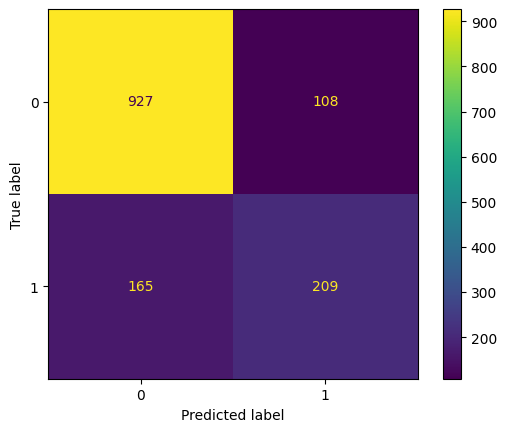

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [48]:
from sklearn.metrics import roc_auc_score

y_prob = log_reg.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8421788214627088


In [49]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_reg.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

print(coef_df.head(10))

                           Feature  Coefficient
10     InternetService_Fiber optic     1.193660
3                     TotalCharges     0.519893
21                 StreamingTV_Yes     0.381099
28  PaymentMethod_Electronic check     0.380941
23             StreamingMovies_Yes     0.380234
26            PaperlessBilling_Yes     0.370366
9                MultipleLines_Yes     0.364331
0                    SeniorCitizen     0.145873
29      PaymentMethod_Mailed check     0.068832
17            DeviceProtection_Yes     0.037195


In [50]:
print(coef_df.tail(10))

                               Feature  Coefficient
12  OnlineSecurity_No internet service    -0.174682
6                       Dependents_Yes    -0.224993
8       MultipleLines_No phone service    -0.258240
19                     TechSupport_Yes    -0.295909
13                  OnlineSecurity_Yes    -0.346818
2                       MonthlyCharges    -0.481375
7                     PhoneService_Yes    -0.500163
24                   Contract_One year    -0.685633
1                               tenure    -1.249330
25                   Contract_Two year    -1.328243


In [51]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree Trained")

Decision Tree Trained


In [52]:
dt_pred = dt_model.predict(X_test)

print(dt_pred[:20])

[0 1 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0]


In [53]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7274662881476224


In [54]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        dt_pred
    )
)

              precision    recall  f1-score   support

           0       0.81      0.82      0.81      1035
           1       0.49      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



In [55]:
from sklearn.metrics import confusion_matrix

dt_cm = confusion_matrix(
    y_test,
    dt_pred
)

print(dt_cm)

[[845 190]
 [194 180]]


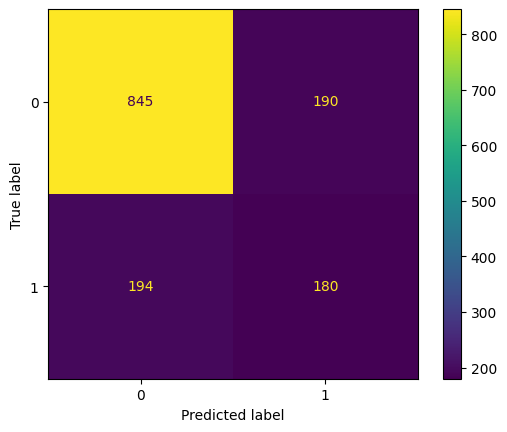

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred
)

plt.show()

In [57]:
from sklearn.metrics import roc_auc_score

dt_prob = dt_model.predict_proba(X_test)[:, 1]

dt_roc_auc = roc_auc_score(
    y_test,
    dt_prob
)

print("Decision Tree ROC-AUC:", dt_roc_auc)

Decision Tree ROC-AUC: 0.648353096179183


In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Trained")

Random Forest Trained


In [59]:
rf_pred = rf_model.predict(X_test)

In [60]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7920511000709723


In [61]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.64      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [62]:
from sklearn.metrics import roc_auc_score

rf_prob = rf_model.predict_proba(X_test)[:,1]

rf_roc_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Random Forest ROC-AUC:", rf_roc_auc)

Random Forest ROC-AUC: 0.8259306621199203


In [65]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "ROC_AUC": [
        roc_auc,
        dt_roc_auc,
        rf_roc_auc
    ]
})

comparison_df = comparison_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

comparison_df

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.806246,0.842179
2,Random Forest,0.792051,0.825931
1,Decision Tree,0.727466,0.648353


In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:")
print(dt_grid.best_params_)

print("\nBest ROC-AUC:")
print(dt_grid.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best ROC-AUC:
0.8178935348520795


In [67]:
best_dt = dt_grid.best_estimator_

best_dt_pred = best_dt.predict(X_test)

from sklearn.metrics import accuracy_score

best_dt_accuracy = accuracy_score(
    y_test,
    best_dt_pred
)

print("Tuned Decision Tree Accuracy:")
print(best_dt_accuracy)

Tuned Decision Tree Accuracy:
0.794180269694819


In [68]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        best_dt_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [69]:
from sklearn.metrics import roc_auc_score

best_dt_prob = best_dt.predict_proba(X_test)[:, 1]

best_dt_roc_auc = roc_auc_score(
    y_test,
    best_dt_prob
)

print("Tuned Decision Tree ROC-AUC:")
print(best_dt_roc_auc)

Tuned Decision Tree ROC-AUC:
0.8267043839933865


In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest ROC-AUC:")
print(rf_grid.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Best ROC-AUC:
0.8431053843537871


In [71]:
best_rf = rf_grid.best_estimator_

best_rf_pred = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score

best_rf_accuracy = accuracy_score(
    y_test,
    best_rf_pred
)

print("Tuned Random Forest Accuracy:")
print(best_rf_accuracy)

Tuned Random Forest Accuracy:
0.8026969481902059


In [72]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        best_rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [73]:
from sklearn.metrics import roc_auc_score

best_rf_prob = best_rf.predict_proba(X_test)[:, 1]

best_rf_roc_auc = roc_auc_score(
    y_test,
    best_rf_prob
)

print("Tuned Random Forest ROC-AUC:")
print(best_rf_roc_auc)

Tuned Random Forest ROC-AUC:
0.8425895786509596


In [74]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Tuned Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        best_dt_accuracy,
        rf_accuracy,
        best_rf_accuracy
    ],
    "ROC_AUC": [
        roc_auc,
        dt_roc_auc,
        best_dt_roc_auc,
        rf_roc_auc,
        best_rf_roc_auc
    ]
})

final_comparison = final_comparison.sort_values(
    by="ROC_AUC",
    ascending=False
)

final_comparison

,Model,Accuracy,ROC_AUC
4,Tuned Random Forest,0.802697,0.842590
0,Logistic Regression,0.806246,0.842179
2,Tuned Decision Tree,0.794180,0.826704
3,Random Forest,0.792051,0.825931
1,Decision Tree,0.727466,0.648353


In [75]:
type(log_reg)

sklearn.linear_model._logistic.LogisticRegression

In [76]:
import joblib

joblib.dump(
    log_reg,
    "../models/logistic_regression_model.pkl"
)

print("Model Saved")

Model Saved


In [77]:
feature_names = X_train.columns.tolist()

joblib.dump(
    feature_names,
    "../models/feature_names.pkl"
)

print("Feature Names Saved")

Feature Names Saved


In [78]:
import os

print(os.listdir("../models"))

['feature_names.pkl', 'logistic_regression_model.pkl']


In [79]:
loaded_model = joblib.load(
    "../models/logistic_regression_model.pkl"
)

print(type(loaded_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [80]:
sample_prediction = loaded_model.predict(
    X_test.iloc[:5]
)

print(sample_prediction)

[0 1 0 0 0]


In [81]:
print(X_train.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [82]:
print(X_train.head())

      SeniorCitizen    tenure  MonthlyCharges  TotalCharges  gender_Male  \
3738              0  0.107048       -0.517207     -0.255041         True   
3151              0 -0.707359        0.343603     -0.497736         True   
4860              0 -0.788800       -0.804698     -0.745327         True   
3867              0 -0.259435        0.290426     -0.165018        False   
3810              0 -1.277445       -0.671755     -0.986125         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
3738        False           False             False   
3151         True            True              True   
4860         True            True             False   
3867         True           False              True   
3810         True            True              True   

      MultipleLines_No phone service  MultipleLines_Yes  ...  \
3738                            True              False  ...   
3151                           False              False  ...   
4860                

In [83]:
print(type(scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>


In [84]:
print(scaler)

StandardScaler()


In [85]:
import joblib

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler Saved")

Scaler Saved


In [86]:
import os

print(os.listdir("../models"))

['feature_names.pkl', 'logistic_regression_model.pkl', 'scaler.pkl']


In [87]:
loaded_scaler = joblib.load(
    "../models/scaler.pkl"
)

print(type(loaded_scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>


# Prediction Pipeline


In [88]:
import pandas as pd
import joblib

model = joblib.load("../models/logistic_regression_model.pkl")
scaler = joblib.load("../models/scaler.pkl")
feature_names = joblib.load("../models/feature_names.pkl")

print("All Objects Loaded")

All Objects Loaded


In [89]:
feature_names


['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'gender_Male',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [90]:
sample_customer = {
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 24,
    "PhoneService": "Yes",
    "MultipleLines": "Yes",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "Yes",
    "OnlineBackup": "No",
    "DeviceProtection": "Yes",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "One year",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Credit card (automatic)",
    "MonthlyCharges": 85.5,
    "TotalCharges": 2052.0
}

sample_customer

{'gender': 'Male',
 'SeniorCitizen': 0,
 'Partner': 'Yes',
 'Dependents': 'No',
 'tenure': 24,
 'PhoneService': 'Yes',
 'MultipleLines': 'Yes',
 'InternetService': 'Fiber optic',
 'OnlineSecurity': 'Yes',
 'OnlineBackup': 'No',
 'DeviceProtection': 'Yes',
 'TechSupport': 'No',
 'StreamingTV': 'Yes',
 'StreamingMovies': 'Yes',
 'Contract': 'One year',
 'PaperlessBilling': 'Yes',
 'PaymentMethod': 'Credit card (automatic)',
 'MonthlyCharges': 85.5,
 'TotalCharges': 2052.0}

In [91]:
sample_df = pd.DataFrame([sample_customer])

sample_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,Yes,No,24,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),85.5,2052.0


In [92]:
sample_df = pd.get_dummies(
    sample_df,
    drop_first=True
)

sample_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,24,85.5,2052.0


In [93]:
sample_df = sample_df.reindex(
    columns=feature_names,
    fill_value=0
)

sample_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,24,85.5,2052.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [94]:
numerical_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

sample_df[numerical_cols] = scaler.transform(
    sample_df[numerical_cols]
)

In [95]:
prediction = model.predict(sample_df)

probability = model.predict_proba(sample_df)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [0]
Probability: [[0.82530902 0.17469098]]


In [96]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [97]:
print(sample_df.T)

                                              0
SeniorCitizen                          0.000000
tenure                                -0.340876
MonthlyCharges                         0.689257
TotalCharges                          -0.100472
gender_Male                            0.000000
Partner_Yes                            0.000000
Dependents_Yes                         0.000000
PhoneService_Yes                       0.000000
MultipleLines_No phone service         0.000000
MultipleLines_Yes                      0.000000
InternetService_Fiber optic            0.000000
InternetService_No                     0.000000
OnlineSecurity_No internet service     0.000000
OnlineSecurity_Yes                     0.000000
OnlineBackup_No internet service       0.000000
OnlineBackup_Yes                       0.000000
DeviceProtection_No internet service   0.000000
DeviceProtection_Yes                   0.000000
TechSupport_No internet service        0.000000
TechSupport_Yes                        0

In [98]:
print(sample_df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [99]:
sample_df = pd.get_dummies(
    sample_df,
    drop_first=True
)

In [100]:
print(sample_df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [101]:
sample_customer = {
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 24,
    "PhoneService": "Yes",
    "MultipleLines": "Yes",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "Yes",
    "OnlineBackup": "No",
    "DeviceProtection": "Yes",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "One year",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Credit card (automatic)",
    "MonthlyCharges": 85.5,
    "TotalCharges": 2052.0
}

test_df = pd.DataFrame([sample_customer])

test_df = pd.get_dummies(
    test_df,
    drop_first=True
)

print(test_df.T)

                     0
SeniorCitizen      0.0
tenure            24.0
MonthlyCharges    85.5
TotalCharges    2052.0


In [102]:
print(type(X))
print(X.shape)

<class 'pandas.DataFrame'>
(7043, 19)


In [103]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [104]:
print(feature_names)

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [105]:
test_df = pd.DataFrame([sample_customer])

test_df_encoded = pd.get_dummies(
    test_df,
    drop_first=True
)

print(test_df_encoded.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [106]:
test_df = pd.DataFrame([sample_customer])

test_df_encoded = pd.get_dummies(
    test_df,
    drop_first=False
)

print(test_df_encoded.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_No', 'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'DeviceProtection_Yes', 'TechSupport_No', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)']


In [107]:
test_df = pd.DataFrame([sample_customer])

test_df_encoded = pd.get_dummies(
    test_df,
    drop_first=False
)

test_df_encoded = test_df_encoded.reindex(
    columns=feature_names,
    fill_value=0
)

print(test_df_encoded.T)

                                            0
SeniorCitizen                               0
tenure                                     24
MonthlyCharges                           85.5
TotalCharges                           2052.0
gender_Male                              True
Partner_Yes                              True
Dependents_Yes                              0
PhoneService_Yes                         True
MultipleLines_No phone service              0
MultipleLines_Yes                        True
InternetService_Fiber optic              True
InternetService_No                          0
OnlineSecurity_No internet service          0
OnlineSecurity_Yes                       True
OnlineBackup_No internet service            0
OnlineBackup_Yes                            0
DeviceProtection_No internet service        0
DeviceProtection_Yes                     True
TechSupport_No internet service             0
TechSupport_Yes                             0
StreamingTV_No internet service   

In [108]:
sample_df = pd.DataFrame([sample_customer])

sample_df = pd.get_dummies(
    sample_df,
    drop_first=False
)

sample_df = sample_df.reindex(
    columns=feature_names,
    fill_value=0
)

sample_df[numerical_cols] = scaler.transform(
    sample_df[numerical_cols]
)

prediction = model.predict(sample_df)

probability = model.predict_proba(sample_df)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [0]
Probability: [[0.58681882 0.41318118]]
